In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader, random_split
import numpy as np
from tqdm import tqdm
import os

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
zip_path = "/content/drive/MyDrive/N4_AI/FINAL/Plant_leaf_diseases_dataset_without_augmentation.zip"
local_data_dir = "/content/dataset"

# Dùng lệnh linux 'unzip' - cực nhanh
!unzip -q "{zip_path}" -d "{local_data_dir}"
print("✅ Giải nén xong chỉ trong 'vài nốt nhạc'!")
data_dir = "/content/dataset/Plant_leave_diseases_dataset_without_augmentation"
print(os.listdir(data_dir))

✅ Giải nén xong chỉ trong 'vài nốt nhạc'!
['Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Corn___healthy', 'Potato___Early_blight', 'Corn___Northern_Leaf_Blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Background_without_leaves', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Blueberry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Grape___Esca_(Black_Measles)', 'Peach___Bacterial_spot', 'Soybean___healthy', 'Grape___healthy', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Grape___Black_rot', 'Pepper,_bell___Bacterial_spot', 'Cherry___Powdery_mildew', 'Tomato___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___healthy', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Apple___healthy', 'Strawberry___Leaf_scorch', 'Orange___Haunglongbing_(Citrus_greening)', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Cherry___healthy', 'Potato___Late_blight', 'Tomato___Leaf_Mold', 'Apple___Apple_scab', 'Tomato

In [ ]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(data_dir)
num_classes = len(dataset.classes)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])

class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, i):
        x,y = self.subset[i]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)

train_ds = ApplyTransform(train_ds, train_tf)
test_ds = ApplyTransform(test_ds, test_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
print(f"Số lượng class nhận diện được: {len(dataset.classes)}")
print(f"Danh sách các lớp: {dataset.classes[:5]}...") # In thử 5 lớp đầu

Số lượng class nhận diện được: 39
Danh sách các lớp: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves']...


In [ ]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

for p in model.classifier.parameters():
    p.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()  # bỏ label smoothing

def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(device)
    return lam*x + (1-lam)*x[index], y, y[index], lam

def mixup_loss(pred, y1, y2, lam):
    return lam*criterion(pred,y1) + (1-lam)*criterion(pred,y2)

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [ ]:
best_acc = 0
patience = 3
counter = 0
epochs = 15

In [ ]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        images, y1, y2, lam = mixup(images, labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = mixup_loss(outputs, y1, y2, lam)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()
    correct, total = 0,0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _,pred = torch.max(outputs,1)
            total += labels.size(0)
            correct += (pred==labels).sum().item()

    acc = 100*correct/total
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")

    scheduler.step()

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/N4_AI/FINAL/best_stage1.pth")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("🛑 Early stopping!")
        break

100%|██████████| 1387/1387 [06:46<00:00,  3.41it/s]


Epoch 1 | Loss: 1.8281 | Acc: 87.51%


100%|██████████| 1387/1387 [06:29<00:00,  3.56it/s]


Epoch 2 | Loss: 1.3018 | Acc: 90.13%


100%|██████████| 1387/1387 [06:05<00:00,  3.80it/s]


...

Epoch 6 | Loss: 1.2132 | Acc: 92.19%


100%|██████████| 1387/1387 [05:54<00:00,  3.91it/s]


Epoch 7 | Loss: 1.1972 | Acc: 91.17%


100%|██████████| 1387/1387 [05:51<00:00,  3.94it/s]


Epoch 8 | Loss: 1.1889 | Acc: 92.36%
🛑 Early stopping!


In [ ]:
print("🚀 Stage 2: Fine-tuning")

# load best model từ Stage 1
model.load_state_dict(torch.load("/content/drive/MyDrive/N4_AI/FINAL/best_stage1.pth"))

# unfreeze deeper layers
for p in model.features[-3:].parameters():
    p.requires_grad = True

# optimizer chỉ update param cần thiết
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.AdamW(params, lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

# early stopping stage 2
best_acc_stage2 = 0
patience = 2
counter = 0

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()
    correct, total = 0,0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _,pred = torch.max(outputs,1)
            total += labels.size(0)
            correct += (pred==labels).sum().item()

    acc = 100*correct/total
    print(f"Stage2 Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")

    scheduler.step()

    # save best
    if acc > best_acc_stage2:
        best_acc_stage2 = acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/N4_AI/FINAL/best_stage2.pth")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("🛑 Early stopping Stage 2!")
        break

# load best stage 2 model
model.load_state_dict(torch.load("/content/drive/MyDrive/N4_AI/FINAL/best_stage2.pth"))

🚀 Stage 2: Fine-tuning


100%|██████████| 1387/1387 [06:03<00:00,  3.82it/s]


Stage2 Epoch 1 | Loss: 0.1434 | Acc: 98.24%


100%|██████████| 1387/1387 [06:01<00:00,  3.84it/s]


Stage2 Epoch 2 | Loss: 0.0643 | Acc: 98.74%


...

100%|██████████| 1387/1387 [06:02<00:00,  3.83it/s]


Stage2 Epoch 4 | Loss: 0.0314 | Acc: 99.05%


100%|██████████| 1387/1387 [06:02<00:00,  3.83it/s]


Stage2 Epoch 5 | Loss: 0.0264 | Acc: 99.30%


<All keys matched successfully>

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": dataset.classes,
    "num_classes": len(dataset.classes),
    "accuracy": best_acc_stage2
}, "/content/drive/MyDrive/N4_AI/FINAL/final_model.pth")

print("🎉 DONE! Model saved.")

🎉 DONE! Model saved.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, loader, class_names):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12,10))
    sns.heatmap(cm, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


📊 Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       1.00      0.96      0.98       131
                            Apple___Black_rot       0.99      1.00      1.00       132
                     Apple___Cedar_apple_rust       1.00      1.00      1.00        58
                              Apple___healthy       0.99      1.00      0.99       294
                    Background_without_leaves       1.00      0.99      0.99       223
                          Blueberry___healthy       1.00      1.00      1.00       284
                      Cherry___Powdery_mildew       1.00      1.00      1.00       199
                             Cherry___healthy       1.00      0.99      1.00       189
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.95      0.92       116
                           Corn___Common_rust       1.00      0.99      1.00       236
                

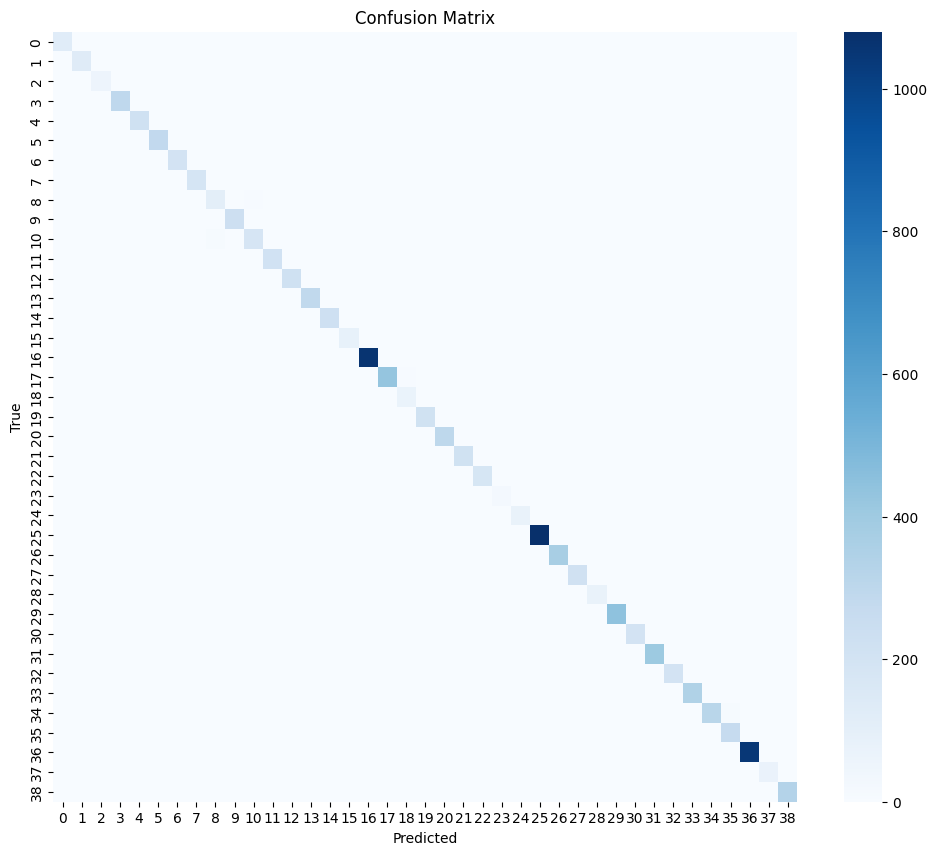

In [ ]:
evaluate_model(model, test_loader, dataset.classes)

In [ ]:
def top_k_accuracy(model, loader, k=3):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, topk = outputs.topk(k, dim=1)
            for i in range(len(labels)):
                if labels[i] in topk[i]:
                    correct += 1
            total += labels.size(0)

    print(f"Top-{k} Accuracy: {100*correct/total:.2f}%")

In [ ]:
top_k_accuracy(model, test_loader, k=3)

Top-3 Accuracy: 99.97%


In [ ]:
def check_confidence(model, loader):
    model.eval()
    confidences = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            conf, _ = torch.max(probs, 1)
            confidences.extend(conf.cpu().numpy())

    import numpy as np
    print(f"Avg confidence: {np.mean(confidences):.4f}")
    print(f"Min confidence: {np.min(confidences):.4f}")
    print(f"Max confidence: {np.max(confidences):.4f}")

In [ ]:
check_confidence(model, test_loader)

Avg confidence: 0.9903
Min confidence: 0.3824
Max confidence: 1.0000


In [ ]:
def evaluate_train_vs_test(model, train_loader, test_loader):
    def get_acc(loader):
        correct, total = 0,0
        model.eval()
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = torch.max(outputs,1)
                total += labels.size(0)
                correct += (pred==labels).sum().item()
        return 100*correct/total

    train_acc = get_acc(train_loader)
    test_acc = get_acc(test_loader)

    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Test Acc: {test_acc:.2f}%")

In [ ]:
evaluate_train_vs_test(model, train_loader, test_loader)

Train Acc: 99.77%
Test Acc: 99.30%


In [ ]:
import matplotlib.pyplot as plt

def show_samples(train_ds, test_ds):
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    img, _ = train_ds[0]
    plt.imshow(img.permute(1,2,0))
    plt.title("Train sample")

    plt.subplot(1,2,2)
    img, _ = test_ds[0]
    plt.imshow(img.permute(1,2,0))
    plt.title("Test sample")

    plt.show()

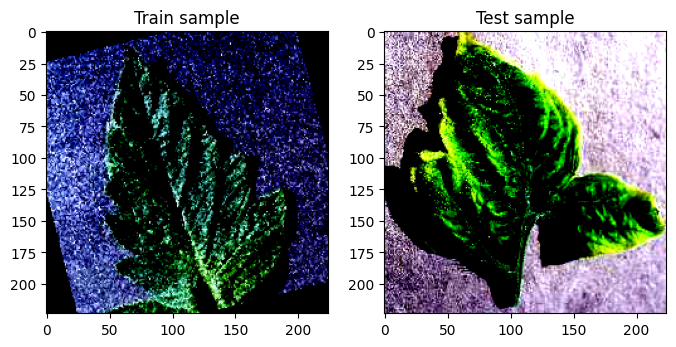

In [ ]:
show_samples(train_ds, test_ds)

In [ ]:
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
classes.sort()

total_images = 0
class_counts = {}

for cls in classes:
    count = len(os.listdir(os.path.join(data_dir, cls)))
    class_counts[cls] = count
    total_images += count

print(f"🌟 Tổng số lớp bệnh: {len(classes)}")
print(f"📸 Tổng số hình ảnh: {total_images}")
print(f"📊 Trung bình mỗi lớp có: {total_images // len(classes)} ảnh")

🌟 Tổng số lớp bệnh: 39
📸 Tổng số hình ảnh: 55448
📊 Trung bình mỗi lớp có: 1421 ảnh


/tmp/ipykernel_2519/1229578344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette="viridis")


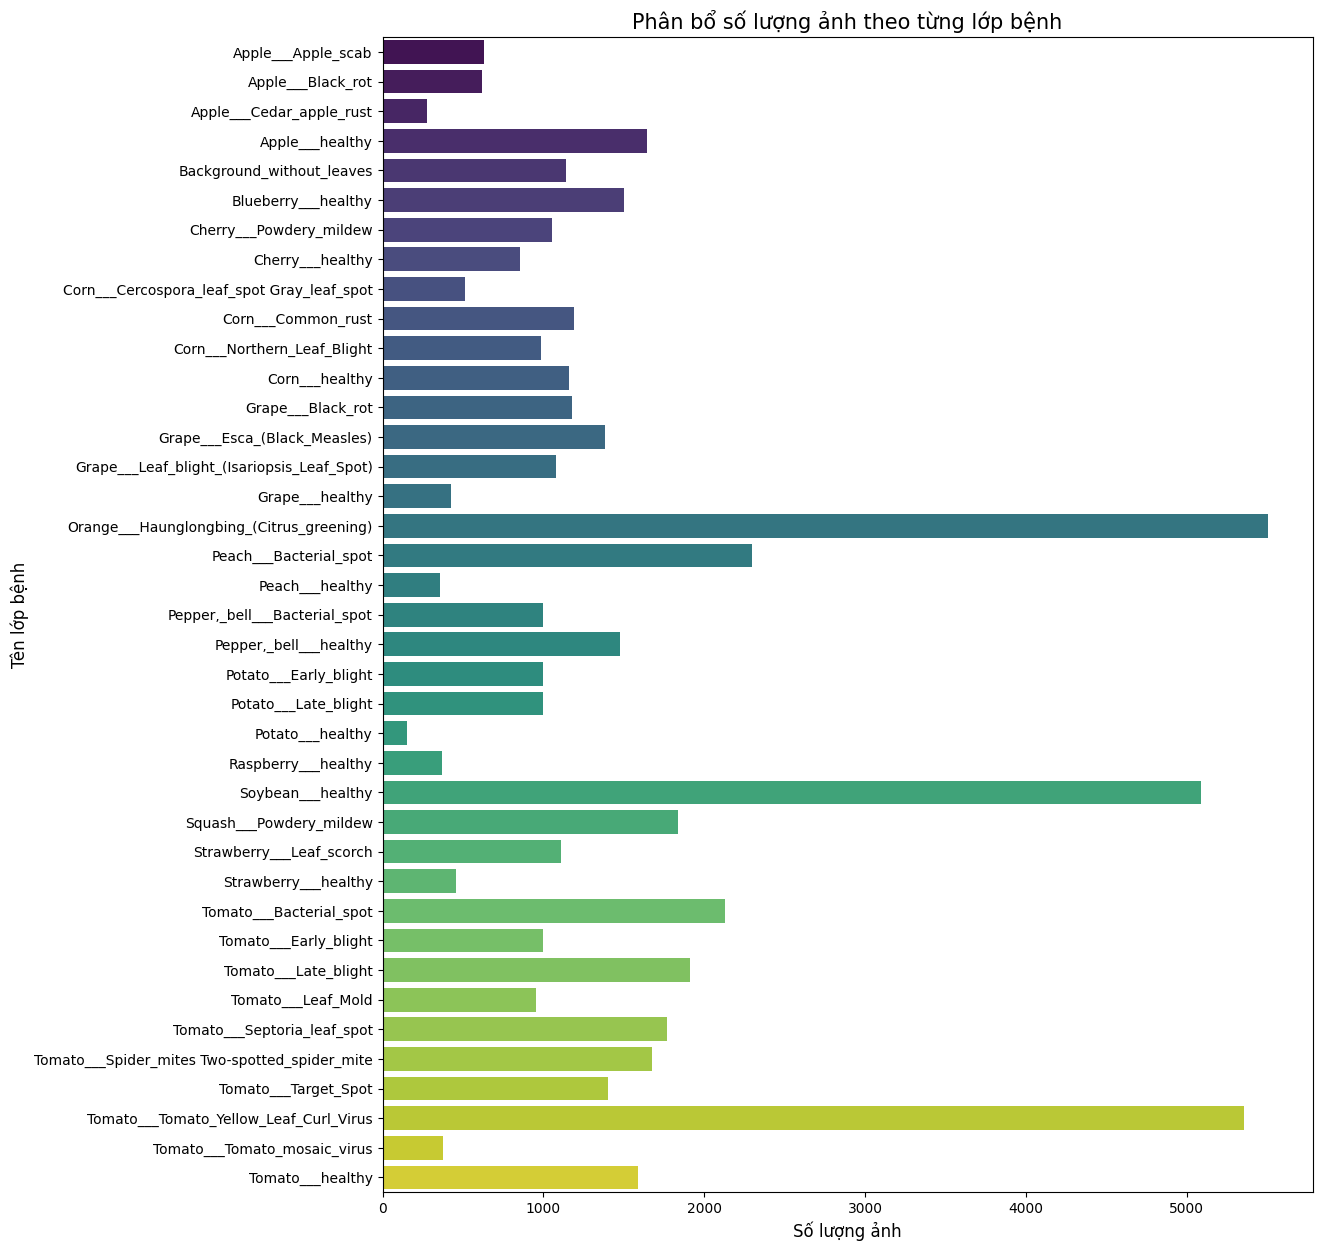

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 15))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette="viridis")
plt.title("Phân bổ số lượng ảnh theo từng lớp bệnh", fontsize=15)
plt.xlabel("Số lượng ảnh", fontsize=12)
plt.ylabel("Tên lớp bệnh", fontsize=12)
plt.show()

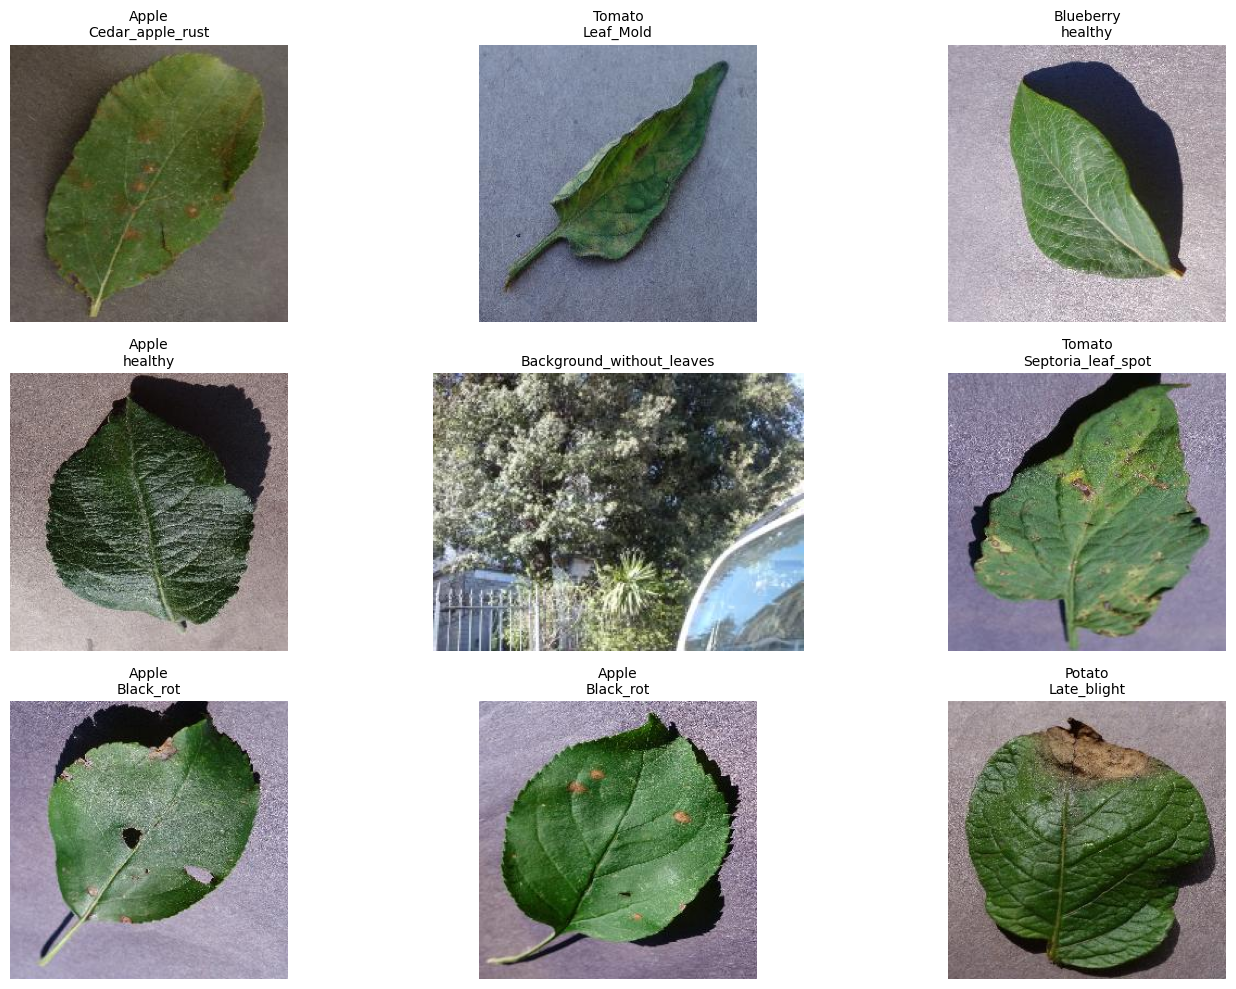

In [ ]:
import matplotlib.image as mpimg
import random

plt.figure(figsize=(15, 10))
for i in range(9):
    # Chọn ngẫu nhiên 1 lớp và 1 ảnh trong lớp đó
    random_class = random.choice(classes)
    random_image = random.choice(os.listdir(os.path.join(data_dir, random_class)))
    img_path = os.path.join(data_dir, random_class, random_image)

    img = mpimg.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(random_class.replace("___", "\n"), fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()